In [2]:
!git clone https://github.com/archie-2006/fake-job-post-detection.git
%cd fake-job-post-detection

Cloning into 'fake-job-post-detection'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 33 (delta 5), reused 24 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 13.59 MiB | 38.56 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/fake-job-post-detection


In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [4]:
!wget -O fake_job_postings.csv https://raw.githubusercontent.com/abbylmm/fake_job_posting/main/data/fake_job_postings.csv

--2026-04-06 15:38:25--  https://raw.githubusercontent.com/abbylmm/fake_job_posting/main/data/fake_job_postings.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50043721 (48M) [text/plain]
Saving to: ‘fake_job_postings.csv’

fake_job_postings.c 100%[===================>]  47.72M   283MB/s    in 0.2s    

2026-04-06 15:38:27 (283 MB/s) - ‘fake_job_postings.csv’ saved [50043721/50043721]



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import itertools
import re
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, f1_score,
                             precision_score, recall_score,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay)

In [6]:
import os

os.makedirs('data/raw', exist_ok=True)
os.makedirs('models', exist_ok=True)

import shutil
shutil.move('fake_job_postings.csv', 'data/raw/fake_job_postings.csv')

'data/raw/fake_job_postings.csv'

In [7]:
!python main.py

 ==== Starting Fake Job Posting Detection Pipeline ==== 

 ==== Loading data set ==== 
Dataset shape: (17880, 18)
Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']
Target distribution:
fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64

 ==== Analyzing class imbalance ==== 
Saved class imbalance plot to figures/class_imbalance.png

 ==== Splitting data ====

[ ~ ] Initializing Preprocessing Pipeline...

[ 1 / 4 ] Cleaning 4 text columns...
  === Done in 2.42s
  === Processed 12516 training rows & 5364 testing rows.

[ 2 / 4 ] Applying TF-IDF Vectorization...
  === Done in 6.49s
  === Extracted 5000 n-gram features.

[ 3 / 4 ] Encoding categorical features...
  === Done in 0.04s
  === Expanded 5 categorical columns into 3770 one-ho

# Fake Job Posting Detection
## 1. Project Overview and Data Loading
This notebook documents the end-to-end pipeline for detecting fraudulent job postings. The dataset exhibits a severe class imbalance, which dictates our evaluation metrics and preprocessing strategy.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import itertools
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

warnings.filterwarnings('ignore')

In [9]:
# Load the raw dataset
df = pd.read_csv('data/raw/fake_job_postings.csv')
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['fraudulent'].value_counts(normalize=True)}")

Dataset shape: (17880, 18)
Target distribution:
fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis
### 2.1 Missing Values & Categorical Fraud Rate
Before modeling, we analyzed missing values, text length distributions, and categorical fraud rates to inform our imputation and feature engineering strategies. We also explored initial word frequencies to identify potential fraud triggers.

* Text columns with missing values will be filled with empty strings.
* Categorical columns with missing values will be explicitly assigned an 'Unknown' category.

In [10]:
# Missing Value Analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
print("Top Missing Value Percentages:")
print(missing_pct[missing_pct > 0].head())

# Categorical Fraud Rate Example
print("\nFraud Rate by Employment Type:")
print(df.groupby('employment_type')['fraudulent'].mean().sort_values(ascending=False))

Top Missing Value Percentages:
salary_range           83.959732
department             64.580537
required_education     45.329978
benefits               40.335570
required_experience    39.429530
dtype: float64

Fraud Rate by Employment Type:
employment_type
Part-time    0.092848
Other        0.066079
Full-time    0.042169
Contract     0.028871
Temporary    0.008299
Name: fraudulent, dtype: float64


### 2.2 Visualizing the Class Imbalance
Understanding the distribution of our target variable is critical. A severe imbalance dictates our entire modeling strategy, from how we split our training data (requiring stratification) to the metrics we must use to evaluate success (prioritizing F1-Score and PR-AUC over standard Accuracy).

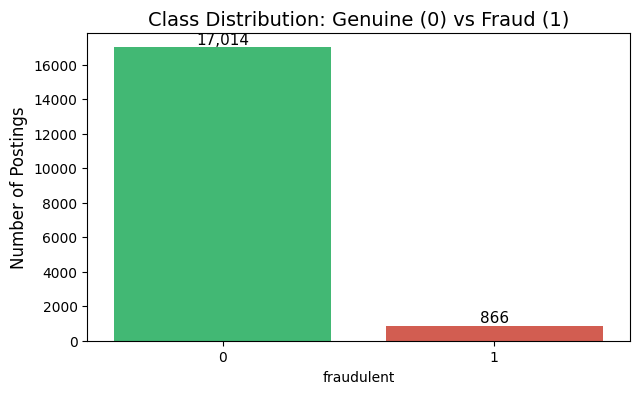

In [11]:
# Visualizing the Severe Class Imbalance
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='fraudulent', palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution: Genuine (0) vs Fraud (1)', fontsize=14)
plt.ylabel('Number of Postings', fontsize=12)

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11)
plt.show()

### 2.3 Text Length Analysis
We hypothesize that fraudulent job postings might have different structural characteristics. Let's compare the word counts of the job descriptions between real and fake postings.

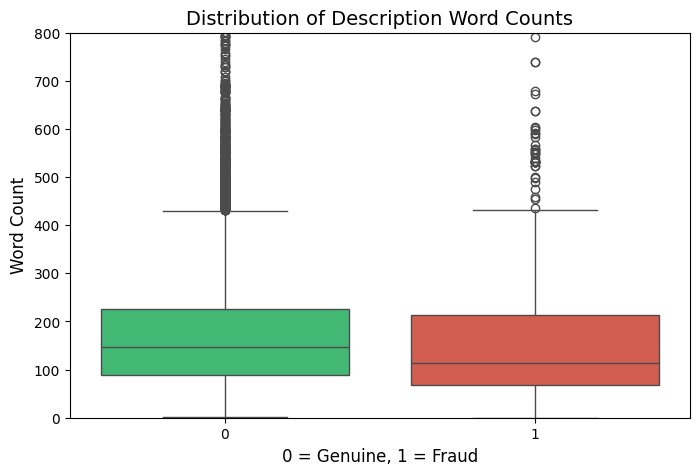

In [12]:
# Calculate word count for descriptions
df['desc_word_count'] = df['description'].astype(str).str.split().str.len()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='fraudulent', y='desc_word_count', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Description Word Counts', fontsize=14)
plt.xlabel('0 = Genuine, 1 = Fraud', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.ylim(0, 800) # Cap outliers to make the boxplot readable
plt.show()

### 2.4 Categorical Risk Factors
Certain job categories attract more fraudulent activity. By plotting the fraud rate (percentage of fake jobs) across different categories, we can see which features will be most valuable for our classifier.

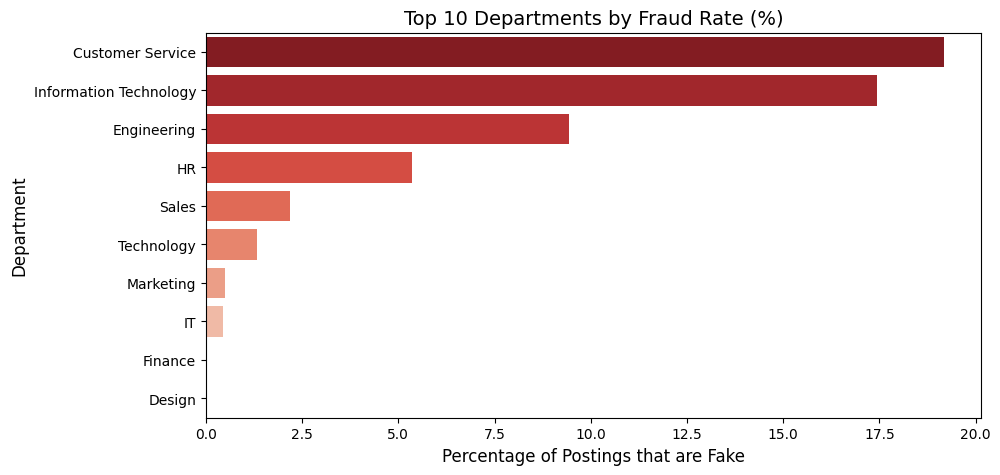

In [13]:
# Calculate fraud rates for top departments
dept_counts = df['department'].value_counts()

# Only look at departments with at least 50 postings to avoid noise
valid_depts = dept_counts[dept_counts > 50].index
dept_fraud_rate = df[df['department'].isin(valid_depts)].groupby('department')['fraudulent'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=dept_fraud_rate.values * 100, y=dept_fraud_rate.index, palette='Reds_r')
plt.title('Top 10 Departments by Fraud Rate (%)', fontsize=14)
plt.xlabel('Percentage of Postings that are Fake', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.show()

### 2.5 Boolean Feature Analysis
Legitimate companies generally have established profiles, while fraudulent posters may skip optional steps to save time. Here, we analyze binary flags—such as the presence of a company logo or screening questions—to test if a lack of verification correlates with higher fraud rates.

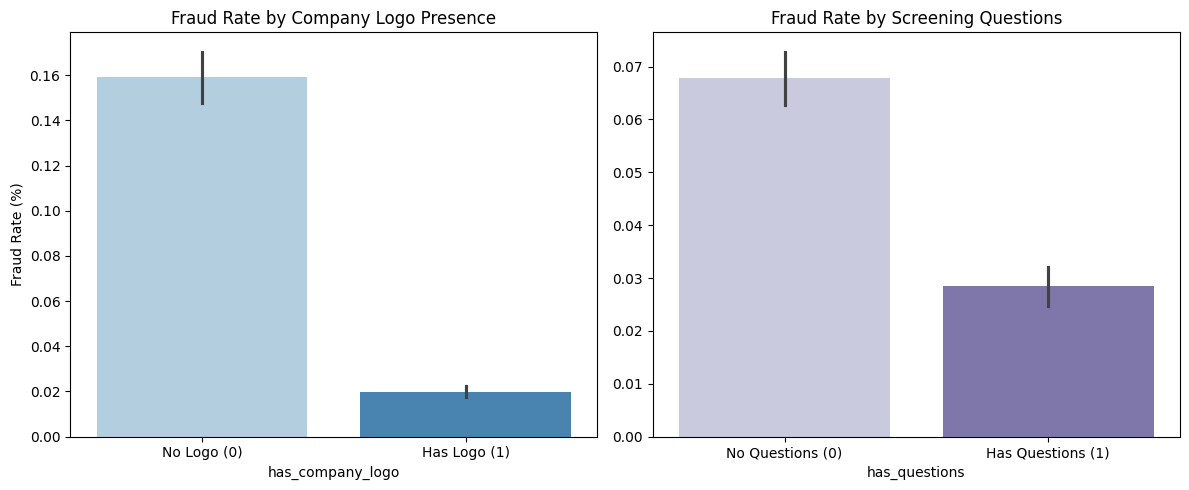

In [14]:
# 1.4 Boolean Feature Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Company Logo (Left Side)
sns.barplot(data=df, x='has_company_logo', y='fraudulent', ax=axes[0], palette='Blues')
axes[0].set_title('Fraud Rate by Company Logo Presence')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticklabels(['No Logo (0)', 'Has Logo (1)'])

# Plot 2: Screening Questions (Right Side)
sns.barplot(data=df, x='has_questions', y='fraudulent', ax=axes[1], palette='Purples')
axes[1].set_title('Fraud Rate by Screening Questions')
axes[1].set_ylabel('') # Remove y-label to keep it clean
axes[1].set_xticklabels(['No Questions (0)', 'Has Questions (1)'])

plt.tight_layout()
plt.show()

### 2.6 Word Frequency in Fraudulent Postings
Before relying on our models to extract feature weights, we can perform a foundational Bag-of-Words analysis. By filtering out common stop words, we isolate the most frequent vocabulary used strictly within fraudulent descriptions to establish our initial fraud-trigger hypothesis.

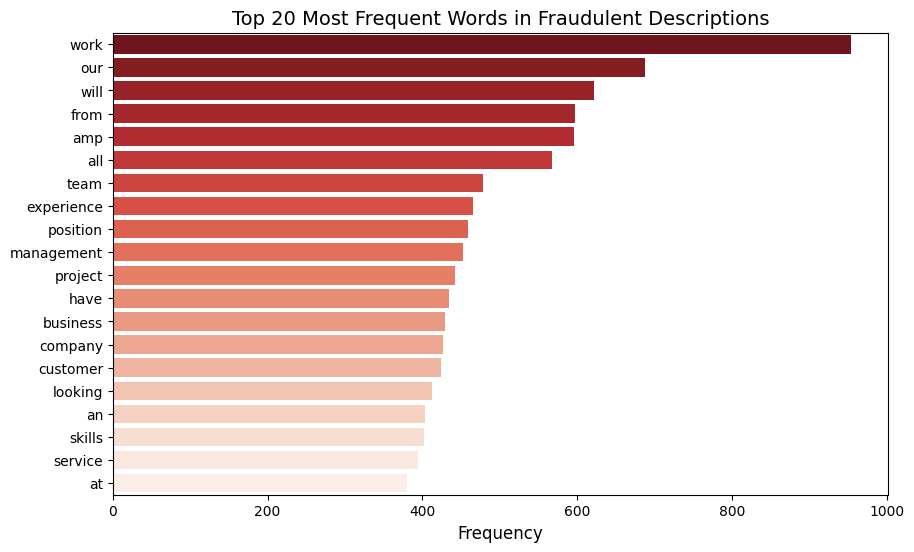

In [15]:
# Isolate fake text
fake_text = df[df['fraudulent'] == 1]['description'].fillna('').str.lower()
fake_text = fake_text.str.replace(r'[^a-z\s]', '', regex=True) # Basic clean

# Count words
all_fake_words = list(itertools.chain.from_iterable(fake_text.str.split()))

# Filter out some basic stop words manually for the EDA plot
stop_words = {'and', 'the', 'to', 'of', 'in', 'a', 'for', 'is', 'with', 'on', 'this', 'you', 'are', 'we', 'be', 'that', 'as', 'it', 'or', 'your'}
filtered_words = [w for w in all_fake_words if w not in stop_words]

word_freq = Counter(filtered_words)
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='Reds_r')
plt.title('Top 20 Most Frequent Words in Fraudulent Descriptions', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.show()

## 3. Preprocessing Pipeline
The preprocessing stage transforms raw text and categorical variables into a sparse matrix. To prevent data leakage, all transformations are fitted exclusively on the training set.

**Methodology:**
* **Text Cleaning:** Lowercasing, HTML tag removal, and whitespace normalization.
* **Train/Test Split:** Stratified 70/30 split to preserve the 5% fraud distribution.
* **TF-IDF Vectorization:** Capped at 5000 features with bigrams to control dimensionality.
* **One-Hot Encoding:** Applied to 5 categorical features, dropping original text.
* **Sparse Stacking:** Combined into a highly memory-efficient compressed sparse row (CSR) matrix.

In [16]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Stratified Split
X = df.drop('fraudulent', axis=1)
y = df['fraudulent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

# Text Processing
text_cols = ['title', 'description', 'requirements', 'company_profile']
X_train_text = X_train[text_cols].fillna('').agg(' '.join, axis=1).apply(clean_text)
X_test_text = X_test[text_cols].fillna('').agg(' '.join, axis=1).apply(clean_text)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7, ngram_range=(1, 2), stop_words='english', dtype=np.float32)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# Categorical Encoding
cat_cols = ['location', 'department', 'employment_type', 'required_experience', 'industry']
cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32)
X_train_cat = cat_encoder.fit_transform(X_train[cat_cols].fillna('Unknown'))
X_test_cat = cat_encoder.transform(X_test[cat_cols].fillna('Unknown'))

# Final Sparse Matrix
X_train_processed = hstack([X_train_tfidf, X_train_cat]).tocsr()
X_test_processed = hstack([X_test_tfidf, X_test_cat]).tocsr()

train_sparsity = 100 * (1.0 - X_train_processed.nnz / (X_train_processed.shape[0] * X_train_processed.shape[1]))

print(f"Final Train Shape: {X_train_processed.shape}")
print(f"Final Test Shape:  {X_test_processed.shape}")
print(f"Matrix Sparsity:   {train_sparsity:.2f}%")

Final Train Shape: (12516, 8770)
Final Test Shape:  (5364, 8770)
Matrix Sparsity:   98.16%


## 4. Machine Learning Modeling
### Import Libraries

In [17]:
import joblib
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

### Load Data and Cross Validation Setup
*(Note: Loading pre-processed data from disk as outputted by main.py)*

In [18]:
X_train = joblib.load('data/processed/X_train.pkl')
y_train = joblib.load('data/processed/y_train.pkl')

print("Shape:", X_train.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Shape: (12516, 8770)


### Naive Bayes

In [19]:
nb = MultinomialNB(alpha=1.0)

f1_nb = cross_val_score(nb, X_train, y_train, cv=cv, scoring='f1')
pr_nb = cross_val_score(nb, X_train, y_train, cv=cv, scoring='average_precision')

print("NB F1:", f1_nb.mean())
print("NB PR-AUC:", pr_nb.mean())

nb.fit(X_train, y_train)
joblib.dump(nb, 'models/nb.pkl')

NB F1: 0.43710170570280005
NB PR-AUC: 0.5714766298674272


['models/nb.pkl']

### Logistic Regression

In [20]:
lr = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

f1_lr = cross_val_score(lr, X_train, y_train, cv=cv, scoring='f1')
pr_lr = cross_val_score(lr, X_train, y_train, cv=cv, scoring='average_precision')

print("LR F1:", f1_lr.mean())
print("LR PR-AUC:", pr_lr.mean())

lr.fit(X_train, y_train)
joblib.dump(lr, 'models/lr_l1.pkl')

LR F1: 0.6690706849227195
LR PR-AUC: 0.7503691277038824


['models/lr_l1.pkl']

### Hyperparameter Tuning

In [21]:
param_grid = {
    'C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

grid = GridSearchCV(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best F1:", grid.best_score_)

best_lr = grid.best_estimator_
joblib.dump(best_lr, 'models/lr_l1_best.pkl')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'C': 5.0}
Best F1: 0.7339766969178042


['models/lr_l1_best.pkl']

### Sparsity Check

In [22]:

coefs = best_lr.coef_[0]

total = len(coefs)
nonzero = np.sum(coefs != 0)

print("Total:", total)
print("Non-zero:", nonzero)
print(f"Sparsity %: {((total - nonzero) / total) * 100:.2f}%")

Total: 8770
Non-zero: 698
Sparsity %: 92.04%



--- Final Test Set Metrics (Logistic Regression L1) ---
F1-Score:  0.7970
PR-AUC:    0.8739
Precision: 0.7726 (When we flag fraud, we are correct 77.3% of the time)
Recall:    0.8231 (We successfully caught 82.3% of all actual frauds)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5104
           1       0.77      0.82      0.80       260

    accuracy                           0.98      5364
   macro avg       0.88      0.91      0.89      5364
weighted avg       0.98      0.98      0.98      5364



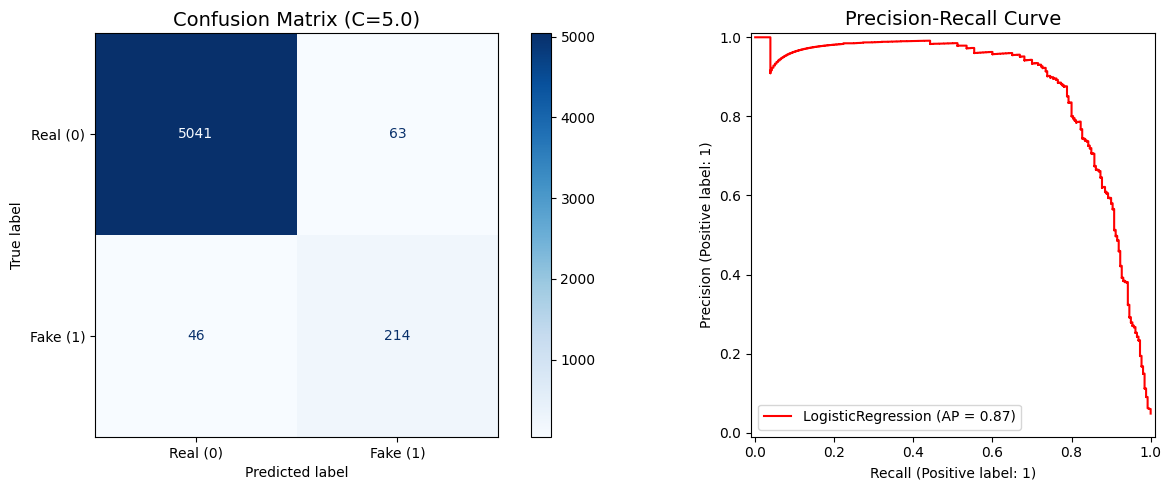

--- L1 Regularization Sparsity Analysis ---
Total Features Passed to Model: 8770
Features Actively Used (Non-Zero): 698
Sparsity Achieved by L1: 92.04%
Conclusion: L1 successfully performed intrinsic feature selection, isolating the core predictors of fraud.

Top 5 Words indicating a FAKE job:
       Feature  Coefficient
          link    26.772747
      aptitude    26.343108
  facilitating    24.181717
amp experience    18.590219
        answer    17.250152

Top 5 Words indicating a REAL job:
  Feature  Coefficient
companies   -26.965825
   search   -14.972036
     team   -14.871074
 starting   -14.184089
      fit   -11.286003


In [23]:
y_pred = best_lr.predict(X_test_processed)
y_proba = best_lr.predict_proba(X_test_processed)[:, 1]

# Calculate Metrics
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n--- Final Test Set Metrics (Logistic Regression L1) ---")
print(f"F1-Score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print(f"Precision: {precision:.4f} (When we flag fraud, we are correct {precision*100:.1f}% of the time)")
print(f"Recall:    {recall:.4f} (We successfully caught {recall*100:.1f}% of all actual frauds)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations (Confusion Matrix & PR Curve)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real (0)', 'Fake (1)'])
disp_cm.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title(f'Confusion Matrix (C={grid.best_params_["C"]})', fontsize=14)

# 2. Precision-Recall Curve
disp_pr = PrecisionRecallDisplay.from_estimator(best_lr, X_test_processed, y_test, ax=axes[1], color='red')
axes[1].set_title('Precision-Recall Curve', fontsize=14)

plt.tight_layout()
plt.show()

# --- L1 Sparsity & Feature Interpretability ---

# Sparsity Analysis
coefficients = best_lr.coef_[0]
total_features = len(coefficients)
nonzero_features = np.sum(coefficients != 0)
sparsity = ((total_features - nonzero_features) / total_features) * 100

print("--- L1 Regularization Sparsity Analysis ---")
print(f"Total Features Passed to Model: {total_features}")
print(f"Features Actively Used (Non-Zero): {nonzero_features}")
print(f"Sparsity Achieved by L1: {sparsity:.2f}%")
print("Conclusion: L1 successfully performed intrinsic feature selection, isolating the core predictors of fraud.\n")

# Extract Feature Names
text_feature_names = vectorizer.get_feature_names_out()
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([text_feature_names, cat_feature_names])

# Combine into DataFrame
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})

# Top Fraud & Genuine Indicators
top_fraud = coef_df.sort_values(by='Coefficient', ascending=False).head(20)
top_genuine = coef_df.sort_values(by='Coefficient', ascending=True).head(20)

print("Top 5 Words indicating a FAKE job:")
print(top_fraud.head(5).to_string(index=False))
print("\nTop 5 Words indicating a REAL job:")
print(top_genuine.head(5).to_string(index=False))


### TF-IDF Word Distribution

Most common words (Lowest IDF):
work, team, skills, years, company, new, time, business, working, looking, management, communication, help, amp, ability

Most informative/rare words (Highest IDF):
bcg, goldleaf, freeze, trak, avastars, weblinc, taxibeat, dyson, echoing, echoing green, ookla, epsilon, omicron, iota, tau
--------------------------------------------------


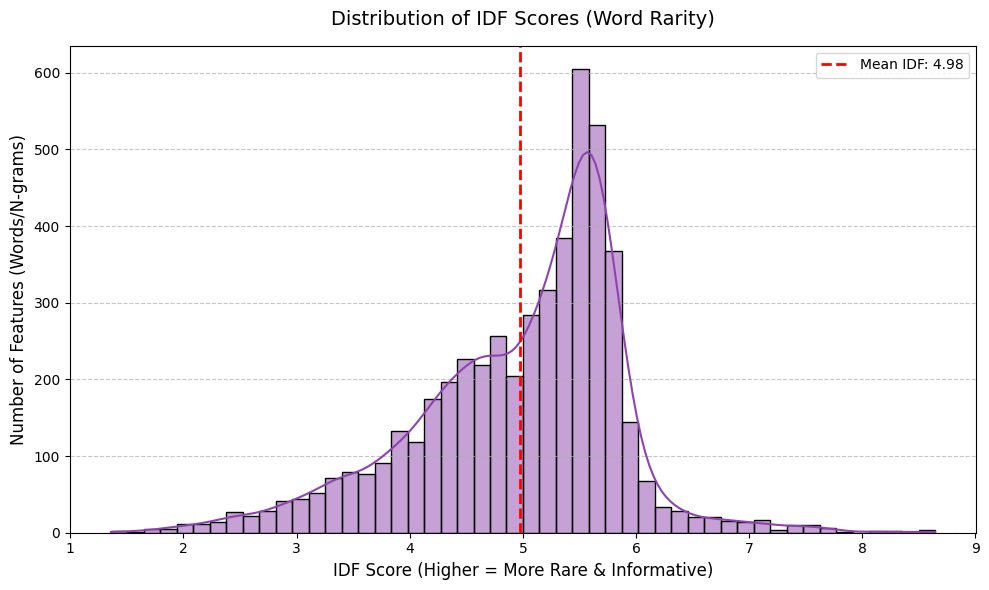

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# 1. Load the saved TF-IDF Vectorizer
try:
    tfidf = joblib.load('models/tfidf_vectorizer.pkl')
    feature_names = tfidf.get_feature_names_out()
    idf_weights = tfidf.idf_

    # 2. Sort the weights to find the extremes
    sorted_idx = np.argsort(idf_weights)
    top_common = [feature_names[i] for i in sorted_idx[:15]]
    top_rare = [feature_names[i] for i in sorted_idx[-15:]]

    print("Most common words (Lowest IDF):")
    print(", ".join(top_common))
    print("\nMost informative/rare words (Highest IDF):")
    print(", ".join(top_rare))
    print("-" * 50)

    # 3. Plot the distribution of IDF scores
    plt.figure(figsize=(10, 6))
    sns.histplot(idf_weights, bins=50, kde=True, color='#8E44AD')
    plt.title('Distribution of IDF Scores (Word Rarity)', fontsize=14, pad=15)
    plt.xlabel('IDF Score (Higher = More Rare & Informative)', fontsize=12)
    plt.ylabel('Number of Features (Words/N-grams)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 4. Add some visual annotations
    plt.axvline(np.mean(idf_weights), color='red', linestyle='dashed', linewidth=2, label=f'Mean IDF: {np.mean(idf_weights):.2f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Couldn't find 'models/tfidf_vectorizer.pkl'. Make sure you ran the main.py script successfully first")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 15.6 MB/s eta 0:00:00


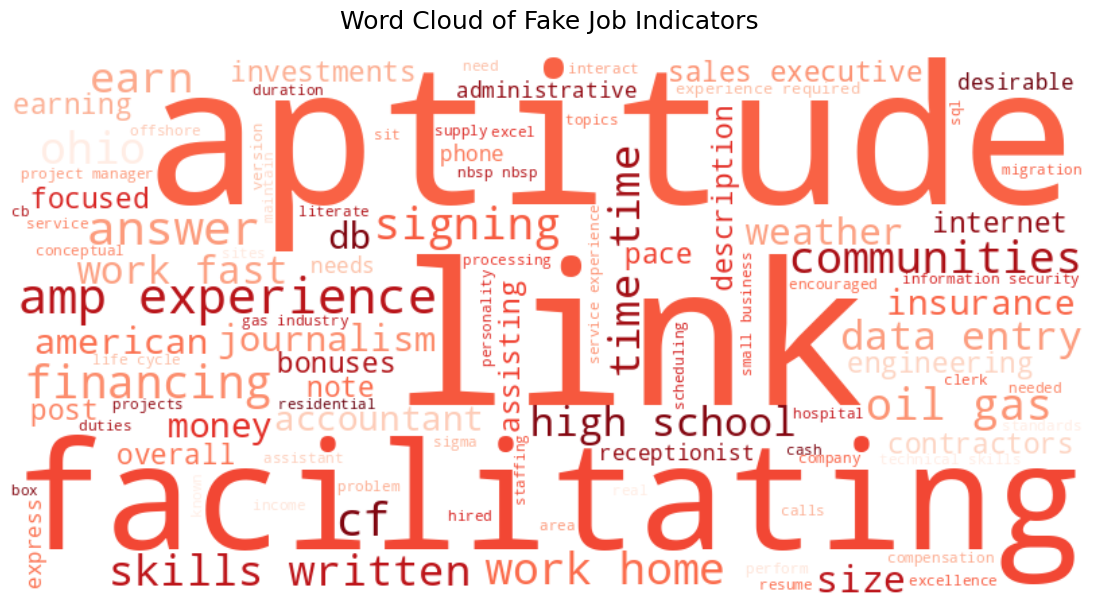

In [25]:
!pip install wordcloud

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
from wordcloud import WordCloud

# 1. Load your best Logistic Regression model and TF-IDF Vectorizer
lr_model = joblib.load('models/lr_l1_best.pkl')
tfidf = joblib.load('models/tfidf_vectorizer.pkl')

# 2. Extract the word features and their coefficients (weights)
# Note: From your logs, the first 5000 features are the TF-IDF words!
word_features = tfidf.get_feature_names_out()
word_coefficients = lr_model.coef_[0][:5000]

# Create a DataFrame to easily sort them
importance_df = pd.DataFrame({
    'Word': word_features,
    'Weight': word_coefficients
})

# Words with the highest POSITIVE weight strongly predict a FAKE job
top_fake_words = importance_df.sort_values(by='Weight', ascending=False).head(20)

#The Word Cloud

# Convert the weights into a dictionary format the WordCloud library understands
# (We only take positive weights that indicate fake jobs)
fake_word_dict = importance_df[importance_df['Weight'] > 0].set_index('Word')['Weight'].to_dict()

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Reds_r',
                      max_words=100).generate_from_frequencies(fake_word_dict)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Fake Job Indicators', fontsize=18, pad=20)
plt.show()

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

### 1. Text Analysis and Characteristics
Analyzing the raw text to see if the length of the postings or specific vocabularies serve as strong discriminators before relying entirely on the model.

In [27]:
text_columns = ['title', 'description', 'requirements', 'company_profile']
text_stats = []

for col in text_columns:
    missing_pct = df[col].isnull().mean() * 100
    avg_words = df[col].dropna().apply(lambda x: len(str(x).split())).mean()
    avg_chars = df[col].dropna().apply(lambda x: len(str(x))).mean()
    text_stats.append({'Column': col, 'Missing %': round(missing_pct, 2), 'Avg Words': round(avg_words, 1), 'Avg Chars': round(avg_chars, 1)})

text_stats_df = pd.DataFrame(text_stats)
print("Text Column Characteristics:")
print(text_stats_df.to_string(index=False))

Text Column Characteristics:
         Column  Missing %  Avg Words  Avg Chars
          title       0.00        3.8       28.5
    description       0.01      170.5     1218.1
   requirements      15.08       91.9      694.9
company_profile      18.50      113.6      761.9


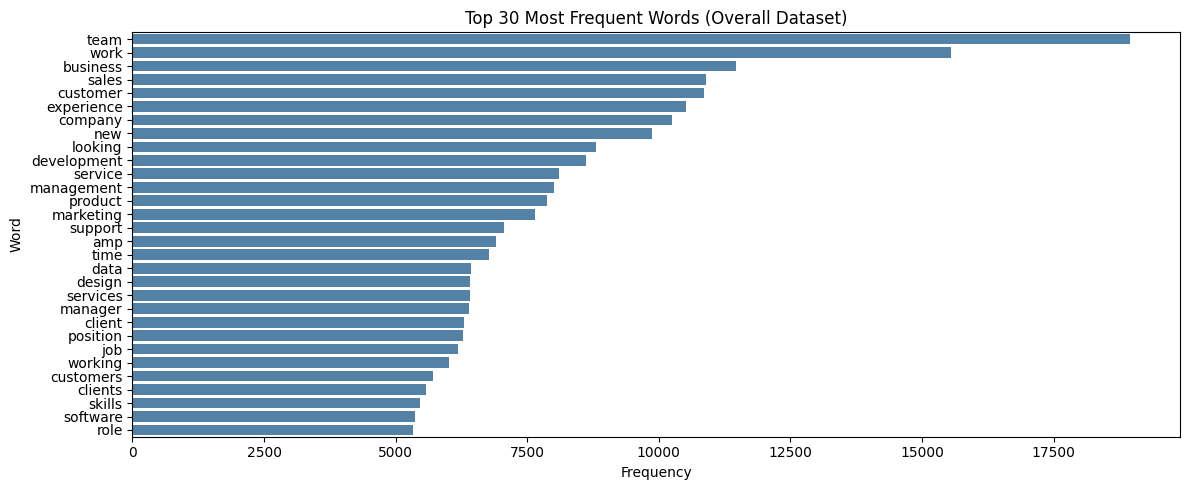

In [28]:
df['combined_text'] = df['title'].fillna('') + ' ' + df['description'].fillna('')

count_vec = CountVectorizer(stop_words='english', max_features=30)
word_counts = count_vec.fit_transform(df['combined_text'])
sum_words = word_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in count_vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words, counts = zip(*words_freq)
plt.figure(figsize=(12, 5))
sns.barplot(x=list(counts), y=list(words), color='steelblue')
plt.title('Top 30 Most Frequent Words (Overall Dataset)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

# Note: Standard business terms dominate the overall dataset. This confirms the need for models to isolate fraud-specific terms.

### 2. Dimensionality Reduction Analysis (PCA / LDA)
Given the high-dimensional sparse matrix, we evaluate if Principal Component Analysis (via TruncatedSVD for sparse matrices) or Linear Discriminant Analysis is mathematically appropriate.

In [29]:
#SVD (PCA for Sparse Matrices) Experiment
n_components_to_test = 100
svd = TruncatedSVD(n_components=n_components_to_test, random_state=42)
X_train_svd = svd.fit_transform(X_train_processed)
explained_variance = svd.explained_variance_ratio_.sum() * 100
print(f"SVD with {n_components_to_test} components explains {explained_variance:.2f}% of the variance.")

n_classes = df['fraudulent'].nunique()
lda_max_components = n_classes - 1
print(f"Linear Discriminant Analysis (LDA) max components for this dataset: {lda_max_components}")

print("\n--- Dimensionality Reduction Conclusion ---")
print("1. SVD/PCA captures variance but destroys feature interpretability by combining text vectors into unreadable components.")
print("2. LDA is mathematically limited to 1 component for binary classification, which causes excessive information loss.")
print("Decision: We will bypass PCA/LDA and rely on L1 Regularization and Tree-based splitting for native, interpretable feature selection.")

SVD with 100 components explains 63.98% of the variance.
Linear Discriminant Analysis (LDA) max components for this dataset: 1

--- Dimensionality Reduction Conclusion ---
1. SVD/PCA captures variance but destroys feature interpretability by combining text vectors into unreadable components.
2. LDA is mathematically limited to 1 component for binary classification, which causes excessive information loss.
Decision: We will bypass PCA/LDA and rely on L1 Regularization and Tree-based splitting for native, interpretable feature selection.


###Decision Tree
We train a Decision Tree. While prone to overfitting on high-dimensional text data, it provides explicit, human-readable Boolean rules for fraud detection.

In [30]:
#Decision Tree Hyperparameter Tuning
dt_param_grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train_processed, y_train)
best_dt = dt_grid.best_estimator_

print("Decision Tree Best Parameters:", dt_grid.best_params_)
print(f"Decision Tree CV F1-Score: {dt_grid.best_score_:.4f}")

Decision Tree Best Parameters: {'max_depth': None, 'min_samples_leaf': 2}
Decision Tree CV F1-Score: 0.5740



--- Decision Tree Test Set Metrics ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      5104
           1       0.56      0.65      0.60       260

    accuracy                           0.96      5364
   macro avg       0.77      0.81      0.79      5364
weighted avg       0.96      0.96      0.96      5364



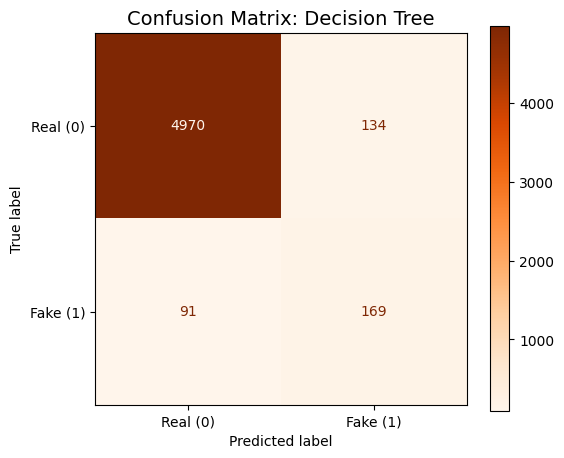

In [31]:
#Decision Tree Evaluation on Test Set
y_pred_dt = best_dt.predict(X_test_processed)

print("\n--- Decision Tree Test Set Metrics ---")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Real (0)', 'Fake (1)'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_dt.plot(cmap='Oranges', values_format='d', ax=ax)
plt.title('Confusion Matrix: Decision Tree', fontsize=14)
plt.show()

###Model Comparison
We extract the Gini importance from the Decision Tree and compare it against the coefficients from the Logistic Regression to isolate robust fraud indicators.

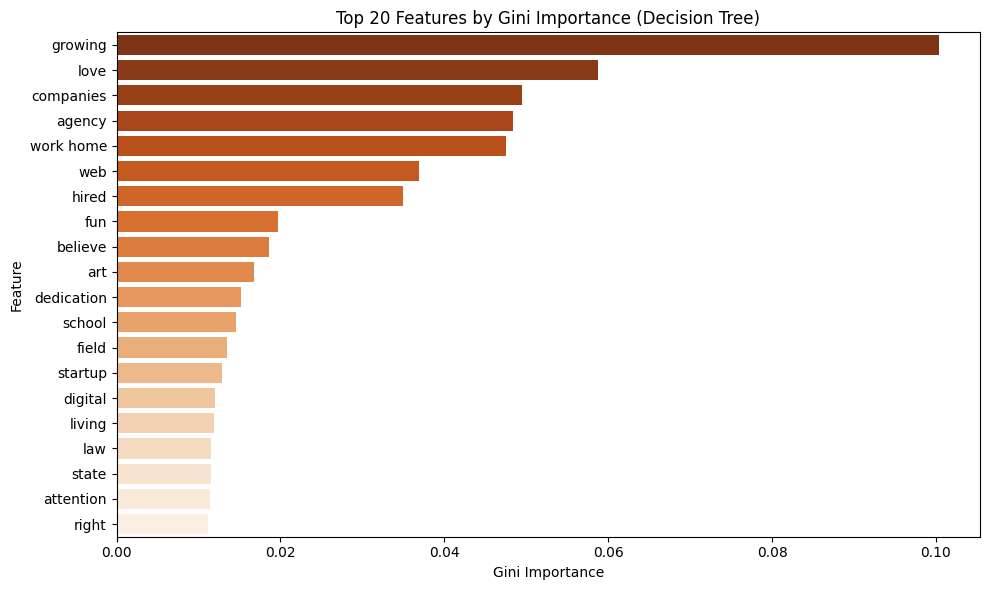

In [32]:
#Decision Tree Top Features
dt_importances = best_dt.feature_importances_
dt_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': dt_importances})
dt_top_20 = dt_imp_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=dt_top_20, palette='Oranges_r')
plt.title('Top 20 Features by Gini Importance (Decision Tree)')
plt.xlabel('Gini Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [33]:
#Overlap Analysis (LR vs DT)
try:
    lr_top_features = set(top_fraud['Feature'].head(20))
    dt_top_features = set(dt_top_20['Feature'])

    overlap = lr_top_features.intersection(dt_top_features)
    print("--- Model Overlap Analysis ---")
    print(f"Features appearing in the Top 20 of BOTH Logistic Regression and Decision Tree: {len(overlap)}")
    print("Robust Fraud Indicators:", list(overlap))
except NameError:
    print("Run the Logistic Regression section first to enable overlap analysis.")

--- Model Overlap Analysis ---
Features appearing in the Top 20 of BOTH Logistic Regression and Decision Tree: 1
Robust Fraud Indicators: ['work home']


In [34]:
#Error Analysis: False Positives and False Negatives
fp_mask = (y_test == 0) & (y_pred_dt == 1)
fn_mask = (y_test == 1) & (y_pred_dt == 0)

print(f"Total False Positives (Legitimate jobs flagged as fake): {fp_mask.sum()}")
print(f"Total False Negatives (Fake jobs that slipped through): {fn_mask.sum()}")

fp_original_indices = X_test[fp_mask].index
print("\nSample False Positive Titles (Legitimate jobs that confused the DT model):")
for title in df.loc[fp_original_indices, 'title'].head(3).values:
    print(f"- {title}")

Total False Positives (Legitimate jobs flagged as fake): 134
Total False Negatives (Fake jobs that slipped through): 91

Sample False Positive Titles (Legitimate jobs that confused the DT model):
- Shyp Hero Courier- SF
- Senior Software Engineer
- Processing Geophysicist


###ROC and Precision-Recall (PR) Curves
For highly imbalanced datasets, Accuracy and standard ROC curves can be misleading. PR-AUC is the metric. Here we visualize the comparative performance of our two primary models.

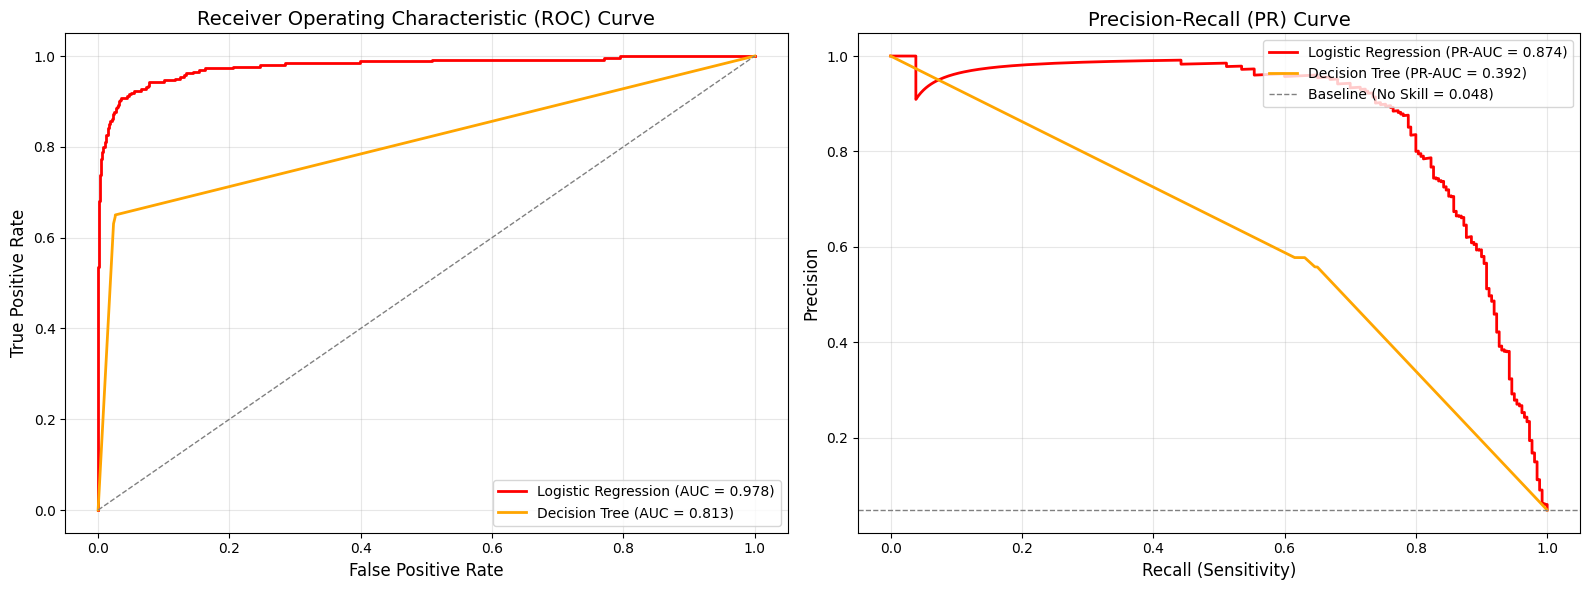

Observation: The PR Curve highlights the true difference in model performance. Logistic Regression handles the sparse, imbalanced space significantly better than the Decision Tree.


In [35]:
# Calculate probabilities for both models
y_prob_lr = best_lr.predict_proba(X_test_processed)[:, 1]
y_prob_dt = best_dt.predict_proba(X_test_processed)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: ROC Curve ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

ax1.plot(fpr_lr, tpr_lr, color='red', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
ax1.plot(fpr_dt, tpr_dt, color='orange', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)
pr_auc_dt = average_precision_score(y_test, y_prob_dt)

baseline_pr = sum(y_test) / len(y_test)

ax2.plot(recall_lr, precision_lr, color='red', lw=2, label=f'Logistic Regression (PR-AUC = {pr_auc_lr:.3f})')
ax2.plot(recall_dt, precision_dt, color='orange', lw=2, label=f'Decision Tree (PR-AUC = {pr_auc_dt:.3f})')
ax2.axhline(y=baseline_pr, color='gray', lw=1, linestyle='--', label=f'Baseline (No Skill = {baseline_pr:.3f})')
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall (PR) Curve', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: The PR Curve highlights the true difference in model performance. Logistic Regression handles the sparse, imbalanced space significantly better than the Decision Tree.")

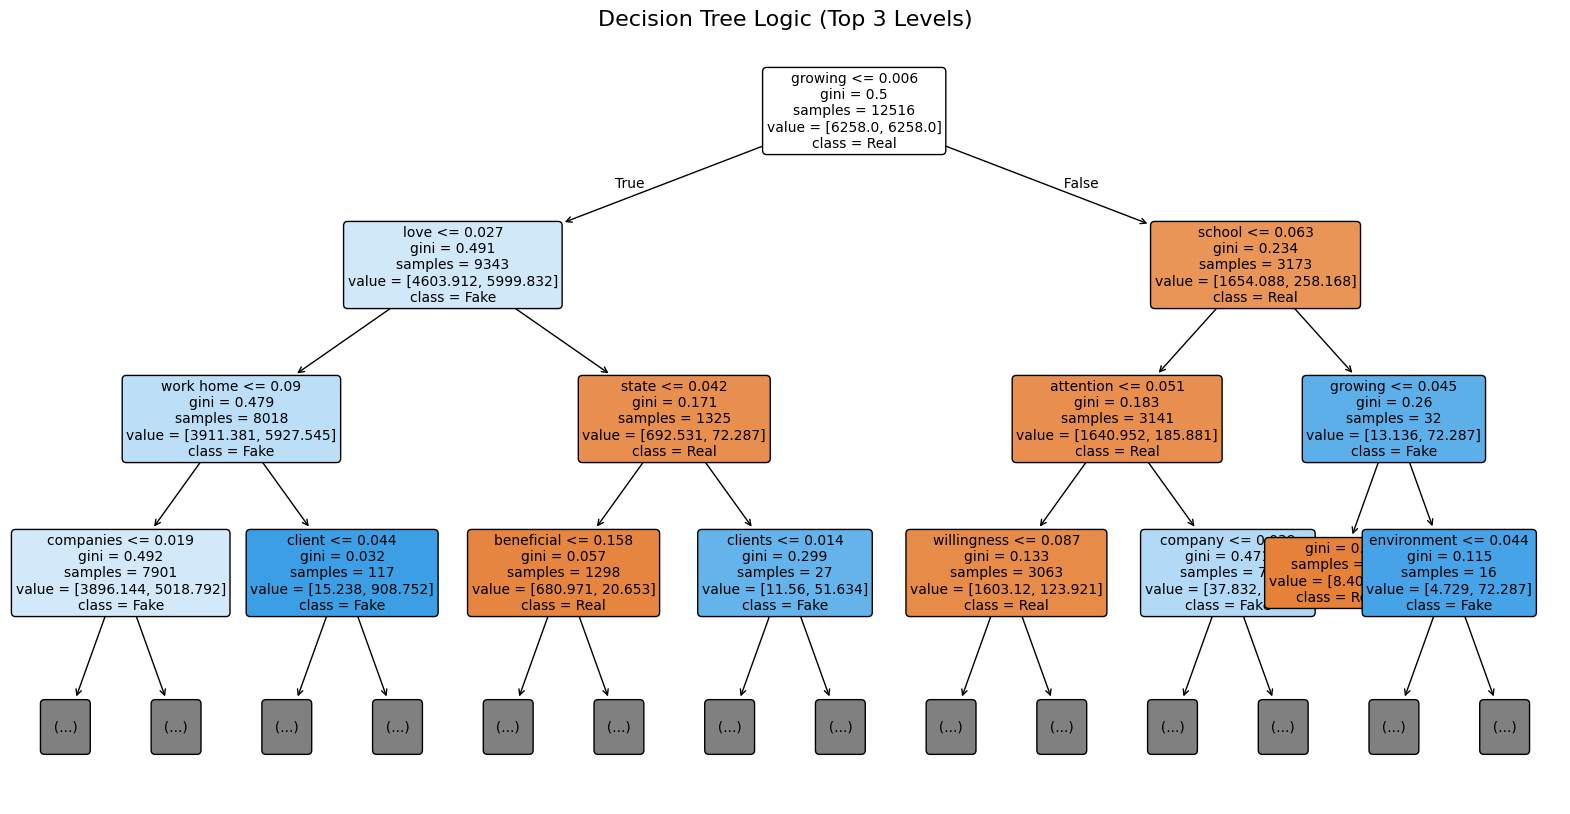

In [36]:
# Tree Visualization for Interpretation
plt.figure(figsize=(20, 10))
plot_tree(best_dt, max_depth=3, feature_names=all_feature_names,
          class_names=['Real', 'Fake'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Logic (Top 3 Levels)', fontsize=16)
plt.show()